In [1]:
import numpy as np
a = range(5)
a = np.array([0,1,2,3,4])
b = np.sort(np.random.choice(a, size=10, replace=True))
a[b]

array([0, 1, 1, 1, 2, 2, 4, 4, 4, 4])

In [2]:
import random
random.randint(0, 1-1)

0

In [3]:
# PyTorch StudioGAN: https://github.com/POSTECH-CVLab/PyTorch-StudioGAN
# The MIT License (MIT)
# See license file or visit https://github.com/POSTECH-CVLab/PyTorch-StudioGAN for details

# src/data_util.py

import os
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, Subset
import torch
import torchvision.transforms as transforms
import numpy as np
import json
import polars as pl
import math
import random
import torch.nn.functional as F
import math

class DropFrames(torch.nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, img):
        # Generate random numbers for all frames at once
        rand_nums = torch.rand(img.shape[0])

        # Create a mask where the random number is less than p
        mask = rand_nums < self.p

        # Set the frames where the mask is True to 0
        img[mask] = 0

        return img

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(p={self.p})"

class DropKeypoints(torch.nn.Module):

    def __init__(self, mask_size, p, cutout_inside=True, mask_color=0):
        super().__init__()
        self.p = p
        self.cutout_inside = cutout_inside
        self.mask_size = mask_size
        self.mask_size_half = mask_size // 2
        self.offset = 1 if mask_size % 2 == 0 else 0
        self.mask_color = mask_color

    def forward(self, img):
        if np.random.random() > self.p:
            return img

        k = img.shape[1]

        if self.cutout_inside:
            ckmin, ckmax = self.mask_size_half, k + self.offset - self.mask_size_half
        else:
            ckmin, ckmax = 0, k + self.offset

        ck = np.random.randint(ckmin, ckmax)
        kmin = ck - self.mask_size_half
        kmax = kmin + self.mask_size
        kmin = max(0, kmin)
        kmax = min(k, kmax)
        img[:,kmin:kmax] = self.mask_color
        return img

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(p={self.p},block_size={self.block_size})"

class RandomCropFrames(torch.nn.Module):
    """
    Crops the random list of frames to the given size.
    """

    def __init__(self, size, window_expand=2):
        super().__init__()
        self.size = size
        self.expanded_size = self.size*window_expand

    def forward(self, img):
        img = torch.permute(img, [1,2,0])
        offset = 0 if img.shape[0]<self.expanded_size else random.randint(0, img.shape[0]-self.expanded_size)
        frames_indexes = np.sort(np.random.choice(range(min(img.shape[0], self.expanded_size)), size=self.size, replace=True)) + offset
        return img[frames_indexes]

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(size={self.size})"

def padding_flex(x, size=0, mode='circular'):
    p = x.shape[-1]
    s = size
    if p>=s:
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    else:
        while s>p:
            x = F.pad(x, pad=(0,p,0,0), mode =mode)
            s-=p
            p+=p
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    return x

class CropFrames(torch.nn.Module):
    """
    Crops the given list of frames to the given size.
    """

    def __init__(self, size):
        super().__init__()
        self.size = size

    def forward(self, img):
        img = torch.permute(img, [1,2,0])
        if img.shape[0]<self.size:
            img = torch.tensor(np.pad(img, ((0, self.size-img.shape[0]),(0,0),(0,0)), 'wrap'))
        elif img.shape[0]>self.size:
            offset = img.shape[0]-self.size
            r = random.randint(0, offset-1)
            img = img[r:-(offset-r)]
        return img

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(size={self.size})"


class RandomAffine(torch.nn.Module):

    def __init__(self, flip_p=0, scale = 0, rot = 0):
        super().__init__()
        self.flip_p = flip_p
        self.scale = scale
        self.rot = rot
                 
    def forward(self, sample):
        flip = -1 if torch.rand(1)<self.flip_p else 1
        random_scale = 1+torch.rand(1).item()*self.scale*2-self.scale
        random_rot = torch.tensor((torch.rand(1).item()*2-1)*self.rot)
        mat = torch.tensor([[flip*random_scale*torch.cos(random_rot), flip*random_scale*-torch.sin(random_rot), 0], 
                        [random_scale*torch.sin(random_rot),      random_scale*torch.cos(random_rot),       0], 
                        [0,                                      0,                                       random_scale]])
        new_sample = sample.flatten(0,1).type(torch.float32) @ mat.T
        return torch.reshape(new_sample, sample.shape)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(flip_p={self.flip_p},scale={self.scale},rot={self.rot})"

class Dataset_(Dataset):
    def __init__(self,
                 data_dir,
                 train,
                 load_data_in_memory=False,
                 poses=None,
                 filter_classes=None,
                 map_classes=None,
                 max_len=15,
                 max_init_len=60,
                 min_samples=0,
                 random_crop=False,
                 drop_frame=0.2,
                 drop_keypoint=0.2,
                 block_size=9,
                 flip_p=0.1,
                 scale=0.5,
                 rot=10):
        super(Dataset_, self).__init__()
        self.data_dir = data_dir
        self.train = train
        self.load_data_in_memory = load_data_in_memory
        self.trsf_list = []
        self.pose_trsf_list = []
        self.poses = poses
        self.filter_classes = filter_classes
        self.map_classes = map_classes
        self.min_samples = min_samples
        self.max_len = max_len
        self.centers = []

        self.trsf_list += [transforms.ToTensor()]
        self.trsf_list += [transforms.Normalize([-0.0224,  0.2656,  0.1731], [0.0641, 0.3551, 0.2297])]
        if random_crop:
            self.trsf_list += [RandomCropFrames(self.max_len)]
        else:
            self.trsf_list += [CropFrames(self.max_len)]
        if flip_p > 0 or scale > 0 or rot > 0:
            self.trsf_list += [RandomAffine(flip_p, scale, rot)]
        if drop_frame>0:
            self.trsf_list += [DropFrames(drop_frame)]
        if drop_keypoint>0:
            self.trsf_list += [DropKeypoints(block_size, drop_keypoint, cutout_inside=True, mask_color=0)]
        self.trsf = transforms.Compose(self.trsf_list)

        self.load_dataset()

    def load_dataset(self):
        mode = "train" if self.train == True else "test"

        # get train/valid sample names
        self.root_ids = os.path.join(self.data_dir, 'metadata', 'splits', mode+'.json')
        with open(self.root_ids) as f:
            data_ids = json.load(f)

        # load all instances
        self.data = pl.read_csv(os.path.join(self.data_dir, 'instances.csv'))

        # filter to only use train/valid predefined samples
        self.data = self.data.filter(pl.col('id').is_in(data_ids))

        # map signs to transform them to their numeric representations
        t_si = pl.read_csv(os.path.join(self.data_dir, 'metadata', 'sign_to_index.csv')).transpose()
        mapping = t_si.rename(t_si.head(1).to_dicts().pop()).slice(1).to_dict(as_series=False)
        mapping = {k: v[0] for k, v in mapping.items()}
        self.data = self.data.with_columns(pl.col('sign').replace(mapping).cast(pl.Int64))

        # get unique classes
        self.classes = self.data.unique('sign')['sign'].to_list()       

        # only keep classes with a number of samples >= min_samples
        if self.min_samples:
            samples_count__dict = {key: 0 for key in self.classes}
            for sign in self.data['sign']:
                samples_count__dict[sign] += 1
            meet_min = []
            for sign, count in samples_count__dict.items():
                if count >= self.min_samples:
                    meet_min.append(sign)

        if self.filter_classes or self.min_samples:
            if self.filter_classes:
                if self.min_samples:
                    selected_classes = list(set(self.filter_classes) & set(meet_min))
                else:
                    selected_classes = self.filter_classes
            else:
                selected_classes = meet_min
            self.data = self.data.filter(pl.col("sign").is_in(selected_classes))
            self.classes = selected_classes
        
        if not self.map_classes:
            self.map_classes = {i:j for i,j in zip(self.classes, range(len(self.classes)))}

    def load(self, index):
        poses_data = []
        take_center = True
        for pose, keypoints in self.poses:
            pose_data = np.load(os.path.join(self.data_dir, 'poses', pose, self.data[index]['id'].item()+'.npy'))
            if keypoints != 'all':
                pose_data = pose_data[:,keypoints,:]
            if take_center:
                self.centers = [pose_data[0,0,0], pose_data[0,0,1], pose_data[0,0,2]]
                take_center = False
            pose_data[:,:,0] -= self.centers[0]
            pose_data[:,:,1] -= self.centers[1]
            pose_data[:,:,2] -= self.centers[2]
            if 'hand' in pose:
                pose_data[:,:,2] = 0
            poses_data.append(pose_data)
        value = np.concatenate(poses_data,axis=1)
        label = self.data[index, 'sign']
        return value, self.map_classes[label]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
            value, label = self.load(index)
            return torch.flatten(self.trsf(value), 1), torch.tensor(label)

class OversamplingWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, oversampling_size=None):
        self.dataset = dataset
        self.data = self.dataset.dataset.data
        self.classes = self.dataset.dataset.classes
        label_dict = {key: [] for key in self.classes}
        for i, sign in enumerate(self.data['sign'].take(self.dataset.indices)):
            label_dict[sign].append(i)
        if oversampling_size:
            self.oversampling_size = oversampling_size
        else:
            self.oversampling_size = max([len(v) for v in label_dict.values()])
        self.num_classes = len(self.classes)
        self.indices = [item for v in label_dict.values() for item in self.multiply(v, self.oversampling_size)]

    def multiply(self, a, n):
        length = len(a)
        new_list = [0] * n
        for i in range(n):
            new_list[i] = a[i % length]
        return new_list

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        return self.dataset[self.indices[index]]


def train_val_dataset(dataset, val_split=0.25, train_size=None, random_state=42, stratify=None):
    train_idx, val_idx = train_test_split(list(range(len(dataset))), test_size=val_split, train_size=train_size, random_state=random_state, stratify=stratify)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

In [4]:
def padding_flex(x, size=0, mode='circular'):
    p = x.shape[-1]
    s = size-p
    if p>=s:
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    else:
        while s>p:
            x = F.pad(x, pad=(0,p,0,0), mode =mode)
            s-=p
            p+=p
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    return x

img = torch.arange(2*4*3).reshape(2,4,3)
m = padding_flex(torch.permute(img, [1,2,0]), 64, "circular")
torch.permute(m, [2,0,1])

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6, 

In [5]:
img = torch.arange(2*4*3).reshape(2,4,3)
img = torch.tensor(np.pad(img, ((1, 1),(0,0),(0,0)), 'wrap'))
img

tensor([[[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]]])

In [6]:
def padding_flex(x, size=0, mode='circular'):
    p = x.shape[-1]
    s = size
    if p>=s:
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    else:
        while s>p:
            x = F.pad(x, pad=(0,p,0,0), mode =mode)
            s-=p
            p+=p
        x = F.pad(x, pad=(0,s,0,0), mode =mode)
    return x

img = torch.arange(2*4*3).reshape(2,4,3)
m = F.pad(torch.permute(img, [1,2,0]), (2, 0, 0, 0), "circular")
torch.permute(m, [2,0,1])

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]]])

In [7]:
m = torch.nn.CircularPad2d((0,1,0,0))
img = torch.arange(2*4*3).reshape(2,4,3)
torch.permute(m(torch.permute(img, [1,2,0])), [2,0,1])

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]]])

In [8]:
import torch.nn as nn
img = torch.arange(2*4*3).reshape(2,4,3)
res = torch.tile(torch.zeros([4,3]),[4, 1, 1])
res[:img.shape[0]] = img
res


tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.],
         [ 6.,  7.,  8.],
         [ 9., 10., 11.]],

        [[12., 13., 14.],
         [15., 16., 17.],
         [18., 19., 20.],
         [21., 22., 23.]],

        [[ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.]],

        [[ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.]]])

In [1]:
# from data.data_util import Dataset_, train_val_dataset, OversamplingWrapper
import utils.misc as misc

lips = [61,39,0,269,291,405,17,181] 
eye_r = [33,159,133,145]
eyebrow_r = [46,52,65,55]
eye_l = [263,386,362,374]
eyebrow_l = [276,282,295,285]
eyes = eye_l+eye_r
eyebrows=eyebrow_l+eyebrow_r

data_name = "LSFB"
data_dir = "/mnt/sda2/datasets/isolated-cont-sl/LSFB/"
poses = [["pose","all"], ["right_hand","all"],["left_hand","all"],["face",lips+eyes+eyebrows]]
num_keypoints = 21+21+33+16

dset_used = 1
seed = 42
oversample = True


In [10]:
print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=29,
                            min_samples=20,
                            drop_frame=0.0,
                            drop_keypoint=0.0,
                            block_size=9,
                            flip_p=0.0,
                            scale=0.0,
                            rot=0)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [14]:
import torch.utils.benchmark as benchmark

def sample():
    return train_dataset[0]

t0 = benchmark.Timer(
    stmt='sample()',
    setup='from __main__ import sample',
    num_threads=4)


print(t0.timeit(4096))

sample()
setup: from __main__ import sample
  1.58 ms
  1 measurement, 4096 runs , 4 threads


In [242]:
print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=29,
                            min_samples=20,
                            drop_frame=0.5,
                            drop_keypoint=0.5,
                            block_size=60,
                            flip_p=0.5,
                            scale=0.5,
                            rot=5)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [243]:
import torch.utils.benchmark as benchmark

def sample():
    return train_dataset[0]

t0 = benchmark.Timer(
    stmt='sample()',
    setup='from __main__ import sample',
    num_threads=4)


print(t0.timeit(100))

sample()
setup: from __main__ import sample
  2.50 ms
  1 measurement, 100 runs , 4 threads


In [207]:
img = train_dataset[0][0][0]

4
64


In [219]:
img[4*3+60*3-1]

tensor(0.)

In [105]:
len(train_dataset.classes)

610

In [106]:
num_keypoints

91

In [107]:
train_dataset.data[11562]

id,sign,signer,start,end
str,i64,str,i64,i64
"""CLSFBI1214A_S0…",0,"""S029""",345501,345653


In [108]:
img[-1]


tensor([[12, 13, 14],
        [15, 16, 17],
        [18, 19, 20],
        [21, 22, 23]])

In [113]:
img = train_dataset[5000][0]
img.shape

torch.Size([29, 297])

In [98]:
res = img
res[:,:,:2] = img[:,:,:2]*torch.tensor([[2.0,2.0]])

TypeError: tuple indices must be integers or slices, not tuple

In [829]:
img[:,:,:2].flatten(0,1).shape

torch.Size([6336, 2])

In [904]:
newxy.shape

torch.Size([99, 2])

In [1403]:
img = torch.ones([5,5,3])

In [1418]:
torch.rand(1).item()*0.5*np.cos(0.5)

0.132099818360619

In [1693]:
def affineMatrix(flip_p, rot, scale):
    flip = -1 if torch.rand(1)<flip_p else 1
    random_rot = torch.rand(1).item()*rot
    random_scale = 1+torch.rand(1).item()*scale
    return np.array([[flip*random_scale*np.cos(random_rot), flip*random_scale*-np.sin(random_rot), 0], [random_scale*np.sin(random_rot), random_scale*np.cos(random_rot), 0], [0,0,1]])

newxy = img[:,:,:].flatten(0,1) @ affineMatrix(0.0, 0.6, 0.0).T
torch.reshape(newxy, img.shape)

tensor([[[ 0.7619, -0.3182, -0.7534],
         [ 0.9880, -0.2671, -0.6533],
         [ 1.1102, -0.1692, -0.6567],
         ...,
         [ 0.3675, -0.9039,  0.8311],
         [ 0.5179, -0.7691,  0.8311],
         [ 0.7002, -0.5902,  0.8438]],

        [[ 0.7616, -0.3179, -0.7324],
         [ 0.9880, -0.2671, -0.6406],
         [ 1.1092, -0.1681, -0.6440],
         ...,
         [ 0.3816, -0.8911,  0.8330],
         [ 0.5292, -0.7589,  0.8330],
         [ 0.7086, -0.5825,  0.8447]],

        [[ 0.7616, -0.3179, -0.7056],
         [ 0.9870, -0.2660, -0.6206],
         [ 1.1092, -0.1681, -0.6240],
         ...,
         [ 0.3911, -0.8844,  0.8340],
         [ 0.5376, -0.7512,  0.8340],
         [ 0.7115, -0.5799,  0.8457]],

        ...,

        [[ 0.7234, -0.3553, -0.7471],
         [ 0.9319, -0.3128, -0.6802],
         [ 1.0579, -0.2075, -0.6821],
         ...,
         [ 0.2794, -0.9768,  0.8384],
         [ 0.4326, -0.8395,  0.8354],
         [ 0.6158, -0.6616,  0.8447]],

        [[

In [62]:
res = torch.zeros([65, img.shape[1], img.shape[2]])
res[:img.shape[0]] = img
res

tensor([[[ 0.3496, -0.7480, -0.7534],
         [ 0.5513, -0.8623, -0.6533],
         [ 0.7075, -0.8721, -0.6567],
         ...,
         [-0.3362, -0.9160,  0.8311],
         [-0.1343, -0.9175,  0.8311],
         [ 0.1210, -0.9077,  0.8438]],

        [[ 0.3496, -0.7480, -0.7534],
         [ 0.5513, -0.8623, -0.6533],
         [ 0.7075, -0.8721, -0.6567],
         ...,
         [-0.3362, -0.9160,  0.8311],
         [-0.1343, -0.9175,  0.8311],
         [ 0.1210, -0.9077,  0.8438]],

        [[ 0.3496, -0.7480, -0.7534],
         [ 0.5513, -0.8623, -0.6533],
         [ 0.7075, -0.8721, -0.6567],
         ...,
         [-0.3362, -0.9160,  0.8311],
         [-0.1343, -0.9175,  0.8311],
         [ 0.1210, -0.9077,  0.8438]],

        ...,

        [[ 0.2961, -0.7495, -0.7471],
         [ 0.4790, -0.8584, -0.6802],
         [ 0.6431, -0.8652, -0.6821],
         ...,
         [-0.4504, -0.9106,  0.8384],
         [-0.2448, -0.9121,  0.8354],
         [ 0.0105, -0.9038,  0.8447]],

        [[

In [106]:
img.size()

torch.Size([64, 99, 3])

In [ ]:
mask = torch.rand((img.shape[0],img.shape[1],img.shape[2])) < 0.9
img*mask

In [713]:
inp = torch.rand([2,10,3])
inp.size()

torch.Size([2, 10, 3])

In [1286]:
import torch.nn.functional as F

block_size = 3
p = 1.0
def calculate_gamma(x):
    """Compute gamma, eq (1) in the paper
    Args:
        x (Tensor): Input tensor
    Returns:
        Tensor: gamma
    """
    
    invalid = (1 - p) / (block_size ** 2)
    valid = (x ** 2) / ((x - block_size + 1) ** 2)
    return invalid * valid

gamma = calculate_gamma(inp.shape[1])
mask = torch.bernoulli(torch.ones((inp.shape[0],inp.shape[1])) * gamma)
mask_block = 1 - F.max_pool1d(
    mask,
    kernel_size=block_size,
    stride=1,
    padding=block_size // 2,
)
mask_ = mask_block.unsqueeze(-1).expand(inp.size())
x = mask_ * inp * (mask_.numel() / mask_.sum())
x

tensor([[[0.5639, 0.9856, 0.9062],
         [0.9756, 0.0927, 0.8910],
         [0.3681, 0.7893, 0.1077],
         [0.3259, 0.1052, 0.2343],
         [0.3739, 0.6996, 0.9057],
         [0.3241, 0.7636, 0.6214],
         [0.3465, 0.8860, 0.8252],
         [0.4801, 0.8142, 0.5923],
         [0.0887, 0.1054, 0.6565],
         [0.6374, 0.4212, 0.4355]],

        [[0.7793, 0.8025, 0.8349],
         [0.9987, 0.2146, 0.5674],
         [0.2994, 0.5628, 0.4985],
         [0.2770, 0.4528, 0.5990],
         [0.2709, 0.9258, 0.4132],
         [0.6138, 0.2981, 0.3554],
         [0.8948, 0.2342, 0.5203],
         [0.7651, 0.6234, 0.9682],
         [0.6449, 0.8384, 0.7465],
         [0.3231, 0.2934, 0.3577]]])

In [702]:
inp

tensor([[[0.1104, 0.9517, 0.5083],
         [0.6447, 0.6457, 0.7080],
         [0.4195, 0.0838, 0.2394],
         [0.8319, 0.4255, 0.9869],
         [0.4669, 0.4579, 0.5663],
         [0.9781, 0.4294, 0.5860],
         [0.4819, 0.7970, 0.0897],
         [0.6962, 0.0247, 0.5147],
         [0.7299, 0.8160, 0.8684],
         [0.8084, 0.7456, 0.1385]]])

In [52]:
pf = 0.0
fkp = 0.5
for frame_i in range(img.shape[0]):
    if pf and torch.rand(1)<pf:
        img[frame_i] = torch.zeros([img.shape[1], img.shape[2]])
    else:
        if fkp:
            for kp_i in range(img.shape[1]):
                if torch.rand(1)<fkp:
                    img[frame_i][kp_i] = torch.zeros([img.shape[2]])
for frame in img:
    print(sum(frame))

tensor([-26.6059,  -1.8915,  -4.8437])
tensor([-19.3875,   3.9120,  -5.9562])
tensor([-30.8274,   5.5185, -11.5387])
tensor([-22.7634,   8.7148,  -4.9623])
tensor([-18.8471,   2.2003,  -3.0435])
tensor([-19.6868,  -1.9828,  -9.6648])
tensor([-25.7900,  -1.5043,  -2.0422])
tensor([-20.0122,   0.1069,  -3.5950])
tensor([-12.5958,  -5.0757,  -3.7369])
tensor([-29.1818,  -0.7602, -10.3056])
tensor([-26.1798,   8.4371,   0.7700])
tensor([-15.9369,  -4.5064,  -1.2502])
tensor([-21.5830,   8.9963,   0.3200])
tensor([-23.0015,  -7.0227,  -7.9124])
tensor([-27.3107,  -5.0651,  -5.1141])
tensor([-29.1854,   2.4637,  -0.6372])
tensor([-0.3792, -4.6442,  0.0065])
tensor([-35.2031,   2.8679,  -4.5852])
tensor([-19.6636,  -1.2107,   1.0947])
tensor([-22.7379,  -5.4717,   1.5249])
tensor([-14.2244,  -0.3532,  -3.6487])
tensor([-16.2475,   3.1756,  -2.5436])
tensor([-11.7839,  -9.3568,  -5.8411])
tensor([-17.1752,  -0.1177,  -4.1329])
tensor([-26.9463,  -9.8504,   2.8911])
tensor([-10.3483,  -4.0063, 

In [192]:
z.shape

torch.Size([3, 20, 99])

In [160]:
z[:,:train_dataset[0][0].shape[1]].shape

torch.Size([3, 13, 99])

In [9]:
train_dataset[20][0].shape

torch.Size([64, 297])

In [36]:
import math
import numpy as np
import random
t = 5
a = np.array([1,2,3,4,5,6,7,8,9,10])
a[int((a.shape[0]-t)/2):-math.ceil((a.shape[0]-t)/2)]

array([3, 4, 5, 6, 7])

In [105]:
import math
import numpy as np
import random
t = 5
a = np.array([1,2,3,4,5,6,7,8,9,10])
offset = a.shape[0]-t
r = random.randint(0, offset-1)
a[r:-(offset-r)]

array([2, 3, 4, 5, 6])

In [98]:
z = torch.zeros([train_dataset[0][0].shape[0], 20,train_dataset[0][0].shape[2]])
z[:,:train_dataset[0][0].shape[1]] = train_dataset[0][0][:]
z

tensor([[[-0.3835,  0.6636,  0.8725,  ..., -0.3396, -0.1348,  0.1327],
         [-0.3958,  0.6673,  0.8725,  ..., -0.3313, -0.1264,  0.1451],
         [-0.4084,  0.6759,  0.8762,  ..., -0.3353, -0.1264,  0.1451],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.8205, -0.9560, -0.9619,  ..., -1.0214, -1.0251, -1.0187],
         [ 0.8275, -0.9608, -0.9662,  ..., -1.0235, -1.0283, -1.0208],
         [ 0.8328, -0.9651, -0.9694,  ..., -1.0246, -1.0289, -1.0224],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.8264, -0.7054, -0.7075,  ...,  1.2554,  1.2468,  1.2479],
         [ 0.6829, -0.5549, -0.5570,  ...,  1

In [24]:
lenghts = []
for i in range(len(train_dataset)):
    lenghts.append(train_dataset[i][0].shape[0])
print(max(lenghts))
print(min(lenghts))

415
4


In [51]:
len(lenghts)

53917

In [66]:
count = 0
for l in lenghts:
    if l > 60:
        count+=1
count

1142

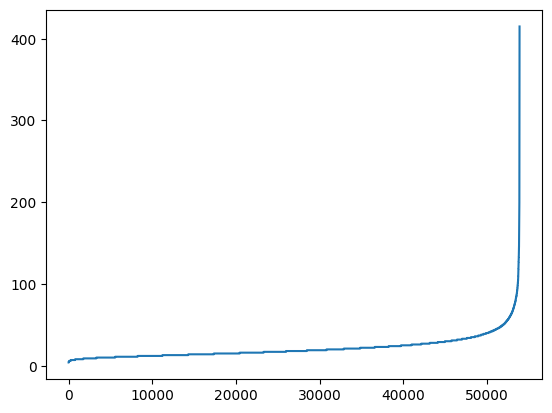

In [25]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.plot(np.sort(lenghts))  # density=False would make counts

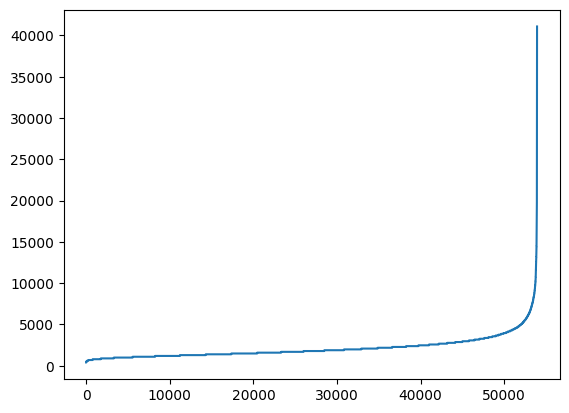

In [35]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.plot(np.sort(lenghts))  # density=False would make counts


In [36]:
np.sort(lenghts)[-300:]

array([ 9009,  9009,  9009,  9009,  9009,  9009,  9009,  9108,  9108,
        9108,  9108,  9108,  9108,  9108,  9108,  9108,  9108,  9108,
        9108,  9207,  9207,  9207,  9207,  9207,  9207,  9207,  9207,
        9207,  9207,  9207,  9207,  9306,  9306,  9306,  9306,  9306,
        9306,  9306,  9306,  9306,  9405,  9405,  9405,  9405,  9405,
        9405,  9405,  9504,  9504,  9504,  9504,  9504,  9504,  9504,
        9504,  9504,  9504,  9504,  9504,  9603,  9603,  9603,  9603,
        9603,  9603,  9603,  9702,  9702,  9702,  9702,  9702,  9702,
        9702,  9702,  9801,  9801,  9801,  9801,  9801,  9801,  9801,
        9801,  9801,  9801,  9801,  9900,  9900,  9900,  9999,  9999,
        9999,  9999,  9999,  9999,  9999,  9999,  9999, 10098, 10098,
       10098, 10098, 10098, 10098, 10098, 10197, 10197, 10197, 10197,
       10197, 10197, 10197, 10296, 10296, 10296, 10296, 10296, 10296,
       10296, 10296, 10296, 10296, 10296, 10395, 10395, 10494, 10494,
       10494, 10494,

In [139]:
subset_size = 100
mean = torch.tensor([0,0,0])
std = torch.tensor([0,0,0])
for index in range(subset_size):
    a = torch.tensor([(train_dataset[index][0][0,:][i].item(), train_dataset[index][0][0,:][i+1].item(), train_dataset[index][0][0,:][i+2].item()) for i in range(0,len(train_dataset[index][0][0,:]),3)])
    mean = mean + torch.mean(a, dim=(0))
    std = std + torch.std(a, dim=(0))
mean = mean / subset_size
std = std / subset_size

In [140]:
mean

tensor([-0.0019, -0.0003, -0.0003])

In [141]:
std

tensor([0.9993, 1.0008, 0.9996])

In [111]:
a = torch.tensor([(train_dataset[index][0][0,:][i].item(), train_dataset[index][0][0,:][i+1].item(), train_dataset[index][0][0,:][i+2].item()) for i in range(0,len(train_dataset[index][0][0,:]),3)])
mean = torch.mean(a, dim=(0))
std = torch.std(a, dim=(0))
std

tensor([0.0554, 0.3642, 0.1898])

In [70]:
train_dataset[0][0][5]

(13, 33, 3)


tensor([ 9.7656e-04, -4.8828e-03,  2.6611e-02,  1.7090e-02, -4.7607e-02,
         4.9561e-02,  2.8076e-02, -4.9316e-02,  4.8828e-02,  3.9062e-02,
        -5.0293e-02,  4.8828e-02, -2.2217e-02, -4.5410e-02,  5.8838e-02,
        -3.4424e-02, -4.4678e-02,  5.8105e-02, -4.5654e-02, -4.3945e-02,
         5.7373e-02,  4.4922e-02, -4.3701e-02,  2.4597e-01, -6.1035e-02,
        -3.4668e-02,  2.7344e-01,  2.2705e-02,  2.4658e-02,  1.1133e-01,
        -1.9287e-02,  2.7832e-02,  1.1743e-01,  1.0986e-01,  1.1694e-01,
         3.3813e-01, -1.0571e-01,  1.3940e-01,  4.9951e-01,  1.3965e-01,
         4.8193e-01,  2.7051e-01, -1.6455e-01,  4.4043e-01,  4.1602e-01,
         3.5156e-02,  3.3154e-01, -6.5918e-03, -8.0811e-02,  3.0127e-01,
         2.0508e-02,  7.5684e-03,  2.7881e-01, -5.9326e-02, -5.1514e-02,
         2.6514e-01, -4.9072e-02,  1.2207e-02,  2.3877e-01, -5.7861e-02,
        -4.7119e-02,  2.2754e-01, -3.7598e-02,  1.0986e-02,  2.5781e-01,
        -3.9062e-03, -5.0537e-02,  2.4463e-01,  1.6

In [103]:
for i in range(len(train_dataset)):
    train_dataset[i]

KeyboardInterrupt: 

In [7]:
train_dataset[0][0]

ValueError: can only call '.item()' if the Series is of length 1, or an explicit index is provided (Series is of length 0)

In [74]:
pose_data.shape

(31, 33, 3)

In [9]:
0 in pose_data.shape

False

In [ ]:
root_ids = os.path.join(data_dir, 'metadata', 'splits', "train"+'.json')
with open(root_ids) as f:
    data_ids = json.load(f)
count = 0
for index in data_ids:
    pose_data = np.load(os.path.join(data_dir, 'poses', "pose", index+'.npy'))
    if 0 in pose_data.shape:
        data_ids.remove(index)
        count += 1
print(count)

# Serializing json
json_object = json.dumps(data_ids, indent=4)
 
# Writing to sample.json
with open(root_ids, "w") as outfile:
    outfile.write(json_object)

In [13]:
root_ids = os.path.join(data_dir, 'metadata', 'splits', "test"+'.json')
with open(root_ids) as f:
    data_ids = json.load(f)
count = 0
for index in data_ids:
    pose_data = np.load(os.path.join(data_dir, 'poses', "pose", index+'.npy'))
    if 0 in pose_data.shape:
        data_ids.remove(index)
        count += 1
print(count)

# Serializing json
json_object = json.dumps(data_ids, indent=4)
 
# Writing to sample.json
with open(root_ids, "w") as outfile:
    outfile.write(json_object)

In [99]:
root_ids = os.path.join(data_dir, 'metadata', 'splits', "train"+'.json')
with open(root_ids) as f:
    data_ids = json.load(f)
count = 0
for index in data_ids:
    pose_data = np.load(os.path.join(data_dir, 'poses', "pose", index+'.npy'))
    if pose_data.shape[0]>60:
        data_ids.remove(index)
        count += 1
print(count)

# Serializing json
json_object = json.dumps(data_ids, indent=4)
 
# Writing to sample.json
with open(root_ids, "w") as outfile:
    outfile.write(json_object)

0


In [ ]:
root_ids = os.path.join(data_dir, 'metadata', 'splits', "test"+'.json')
with open(root_ids) as f:
    data_ids = json.load(f)
count = 0
for index in data_ids:
    pose_data = np.load(os.path.join(data_dir, 'poses', "pose", index+'.npy'))
    if pose_data.shape[0]>60:
        data_ids.remove(index)
        count += 1
print(count)

# Serializing json
json_object = json.dumps(data_ids, indent=4)
 
# Writing to sample.json
with open(root_ids, "w") as outfile:
    outfile.write(json_object)

In [12]:
# Serializing json
json_object = json.dumps(data_ids, indent=4)
 
# Writing to sample.json
with open(root_ids, "w") as outfile:
    outfile.write(json_object)

In [10]:
import numpy as np
import os

np.load("/mnt/sda2/datasets/isolated-cont-sl/LSFB/poses/pose/CLSFBI0210A_S003_B_518802_519101.npy")

array([], shape=(0, 33, 3), dtype=float16)

In [69]:
len(data_ids)

67587

In [40]:
data = pl.read_csv(os.path.join(data_dir, 'instances_special.csv'))
data

id,sign,signer,start,end
str,str,str,i64,i64
"""CLSFBI0103A_S0…","""PT:PRO2""","""S001""",251377,251488
"""CLSFBI0103A_S0…","""PT:POSS2""","""S001""",252353,252691
"""CLSFBI0103A_S0…","""PT:PRO2""","""S001""",283902,285174
"""CLSFBI0103A_S0…","""LBUOY""","""S001""",285448,285699
"""CLSFBI0103A_S0…","""PT:PRO1""","""S001""",286406,286613
"""CLSFBI0103A_S0…","""PT:PRO4""","""S001""",286939,287559
"""CLSFBI0103A_S0…","""PT:PRO4""","""S001""",289380,290166
"""CLSFBI0103A_S0…","""PT:PRO1""","""S001""",290605,292296
"""CLSFBI0103A_S0…","""PT:POSS1""","""S001""",293252,293443


In [7]:
import os
import json
import polars as pl
root_ids = os.path.join(data_dir, 'metadata', 'splits', "test"+'.json')
with open(root_ids) as f:
    data_ids = json.load(f)
    
# load all instances
data = pl.read_csv(os.path.join(data_dir, 'instances.csv'))

# filter to only use train/valid predefined samples
#predicate = pl.any_horizontal(pl.col('id') == v for v in data_ids)

datafiltered = data.filter(pl.col('id').is_in(data_ids))
datafiltered[0]['id'].item()

'CLSFBI0103A_S001_B_251203_251361'

In [10]:
len(train_dataset.classes)

637

In [4]:
train_dataset, valid_dataset = train_val_dataset(dataset = train_dataset, val_split=0.1, random_state = seed, stratify=train_dataset.data['sign'].to_list())

print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))
print("Valid dataset size: {dataset_size}".format(dataset_size=len(valid_dataset)))

Train dataset size: 49059
Valid dataset size: 5451


In [5]:
if dset_used > 1:
    dset_used = int
elif dset_used < 1:
    dset_used = 1 - dset_used
else:
    dset_used = dset_used
if dset_used != 1:
    train_dataset, _ = train_val_dataset(dataset = train_dataset, val_split=None, train_size=dset_used, random_state = seed)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))

Train dataset size: 49059


In [6]:
if oversample:
    train_dataset = OversamplingWrapper(train_dataset)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))

Train dataset size: 1017926


In [7]:
print("Load {name} test dataset.".format(name=data_name))
test_dataset = Dataset_(data_dir=data_dir,
                        train=False,
                        load_data_in_memory=False,
                        filter_classes=train_dataset.classes,
                        map_classes=train_dataset.dataset.dataset.map_classes,
                        poses=poses)
print("Test dataset size: {dataset_size}".format(dataset_size=len(test_dataset)))

Load LSFB test dataset.


Test dataset size: 41338


In [8]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_dataset,
                                batch_size=16,
                                shuffle=True,
                                pin_memory=True,
                                num_workers=4,
                                drop_last=True,
                                persistent_workers=True)
valid_dataloader = DataLoader(dataset=valid_dataset,
                                batch_size=16,
                                shuffle=False,
                                pin_memory=True,
                                num_workers=4,
                                drop_last=False)
test_dataloader = DataLoader(dataset=test_dataset,
                                batch_size=16,
                                shuffle=False,
                                pin_memory=True,
                                num_workers=4,
                                drop_last=False)


In [3]:
test_dataset[10000]

NameError: name 'test_dataset' is not defined

In [23]:
next(iter(train_dataloader))

NameError: name 'train_dataloader' is not defined

In [11]:
max_len = 0 
max_len_index = 0
min_len = 9999
min_len_index = 0
for i in range(len(train_dataset)):
    lenght = train_dataset[i][0].shape[0]
    if lenght>max_len:
        max_len = lenght
        max_len_index = i
    if lenght<min_len:
        min_len = lenght
        min_len_index = i
print(max_len)
print(max_len_index)
print(min_len)
print(min_len_index)

KeyboardInterrupt: 

In [27]:
train_dataset[5][0]

tensor([[ 0.4287,  0.3364,  0.0000,  ...,  0.4961,  0.2971, -0.0200],
        [ 0.4265,  0.3374,  0.0000,  ...,  0.4946,  0.2961, -0.0212],
        [ 0.4241,  0.3384,  0.0000,  ...,  0.4932,  0.2959, -0.0226],
        ...,
        [ 0.4221,  0.3589,  0.0000,  ...,  0.4912,  0.2969, -0.0256],
        [ 0.4216,  0.3640,  0.0000,  ...,  0.4910,  0.2966, -0.0257],
        [ 0.4216,  0.3684,  0.0000,  ...,  0.4922,  0.2964, -0.0250]],
       dtype=torch.float16)

In [ ]:
{i:j for i,j in zip(train_dataset.classes, range(len(train_dataset.classes)))}

{331: 0,
 736: 1,
 75: 2,
 66: 3,
 12: 4,
 730: 5,
 420: 6,
 337: 7,
 78: 8,
 667: 9,
 170: 10,
 167: 11,
 417: 12,
 462: 13,
 27: 14,
 84: 15,
 188: 16,
 286: 17,
 349: 18,
 301: 19,
 176: 20,
 69: 21,
 3: 22,
 0: 23,
 673: 24,
 158: 25,
 435: 26,
 551: 27,
 304: 28,
 173: 29,
 587: 30,
 578: 31,
 33: 32,
 840: 33,
 42: 34,
 530: 35,
 432: 36,
 215: 37,
 227: 38,
 471: 39,
 30: 40,
 268: 41,
 569: 42,
 396: 43,
 459: 44,
 352: 45,
 346: 46,
 733: 47,
 542: 48,
 283: 49,
 63: 50,
 9: 51,
 185: 52,
 93: 53,
 411: 54,
 203: 55,
 608: 56,
 149: 57,
 191: 58,
 36: 59,
 274: 60,
 310: 61,
 703: 62,
 146: 63,
 483: 64,
 343: 65,
 658: 66,
 224: 67,
 807: 68,
 316: 69,
 298: 70,
 715: 71,
 581: 72,
 527: 73,
 319: 74,
 560: 75,
 489: 76,
 313: 77,
 221: 78,
 456: 79,
 444: 80,
 206: 81,
 60: 82,
 143: 83,
 39: 84,
 182: 85,
 334: 86,
 21: 87,
 408: 88,
 292: 89,
 57: 90,
 447: 91,
 307: 92,
 480: 93,
 155: 94,
 48: 95,
 194: 96,
 685: 97,
 164: 98,
 661: 99,
 399: 100,
 295: 101,
 322: 102,
 

In [40]:
train_dataset[3]

(tensor([[ 0.3896,  0.3835,  0.0000,  ...,  0.4800,  0.3013, -0.0109],
         [ 0.3896,  0.3752,  0.0000,  ...,  0.4805,  0.3027, -0.0114],
         [ 0.3894,  0.3691,  0.0000,  ...,  0.4814,  0.3032, -0.0126],
         ...,
         [ 0.3728,  0.3984,  0.0000,  ...,  0.4844,  0.3049, -0.0137],
         [ 0.3662,  0.4043,  0.0000,  ...,  0.4851,  0.3069, -0.0142],
         [ 0.3564,  0.4116,  0.0000,  ...,  0.4866,  0.3086, -0.0147]],
        dtype=torch.float16),
 tensor(302))

In [32]:
hand = train_dataset[3][0]
hand[:,:,2] = 0

IndexError: too many indices for tensor of dimension 2

In [15]:
print(a)

[(0.33154296875, 0.461669921875), (0.358642578125, 0.444580078125), (0.380859375, 0.440673828125), (0.3955078125, 0.454833984375), (0.4013671875, 0.47802734375), (0.374267578125, 0.395751953125), (0.394287109375, 0.440185546875), (0.402587890625, 0.47314453125), (0.408447265625, 0.4951171875), (0.35498046875, 0.407958984375), (0.37890625, 0.46240234375), (0.3828125, 0.490478515625), (0.382568359375, 0.50341796875), (0.338134765625, 0.426513671875), (0.363037109375, 0.4765625), (0.3681640625, 0.497802734375), (0.3671875, 0.50537109375), (0.325439453125, 0.4462890625), (0.346923828125, 0.4814453125), (0.35302734375, 0.495361328125), (0.35302734375, 0.499267578125), (0.495361328125, 0.82275390625), (0.474365234375, 0.78369140625), (0.4501953125, 0.755859375), (0.431884765625, 0.72998046875), (0.423095703125, 0.70458984375), (0.42724609375, 0.8017578125), (0.391845703125, 0.80517578125), (0.37060546875, 0.8095703125), (0.35400390625, 0.814453125), (0.425537109375, 0.8310546875), (0.3850097

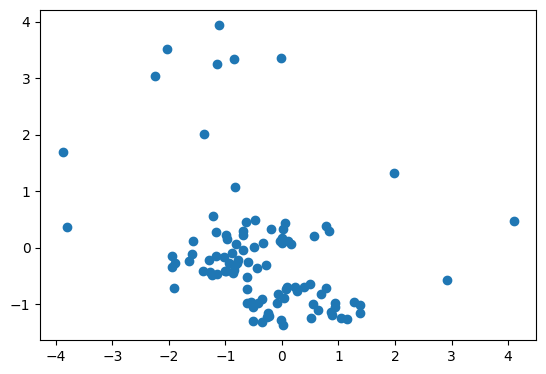

In [64]:
import matplotlib.pyplot as plt
%matplotlib inline

index = 8
a = [(train_dataset[index][0][0,:][i].item(), train_dataset[index][0][0,:][i+1].item()) for i in range(0,len(train_dataset[index][0][0,:]),3)]

fig, ax = plt.subplots()
ax.scatter(*zip(*a))
ax.set_aspect('equal')
plt.show()

In [112]:
poses = [["pose","all"]]
# poses = [["right_hand","all"],["left_hand","all"],["pose","all"], ["face",[57,61,185,40,39,37,0,267,269,270,409,291,375,321,405,314,17,84,181,91,146,287,
        #78,191,80,81,82,13,312,311,310,415,308,324,318,402,317,14,87,178,88,95,33,246,161,160,159,158,157,173,133,155,154,153,145,144,163,7,124,46,53,
        #52,65,55,113,225,224,223,222,221,263,466,388,387,386,385,384,398,362,382,381,380,374,373,390,249,353,276,283,282,295,285,342,445,444,443,442,441]]]

print("Load {name} train dataset.".format(name=data_name))
pose_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=15,
                            min_samples=20)
print("Train dataset size: {dataset_size}".format(dataset_size=len(pose_dataset)))

Load LSFB train dataset.
Train dataset size: 52350


In [10]:
a = np.zeros([5,2,3])
a[:,:,0]-=1
a

array([[[-1.,  0.,  0.],
        [-1.,  0.,  0.]],

       [[-1.,  0.,  0.],
        [-1.,  0.,  0.]],

       [[-1.,  0.,  0.],
        [-1.,  0.,  0.]],

       [[-1.,  0.,  0.],
        [-1.,  0.,  0.]],

       [[-1.,  0.,  0.],
        [-1.,  0.,  0.]]])

In [ ]:
for i in range(len(pose_dataset)):

In [18]:
for i in range(len(pose_dataset)):
    lenght = pose_dataset[i][0].shape[0]
    if lenght>300:
        print(i)
        break

11562


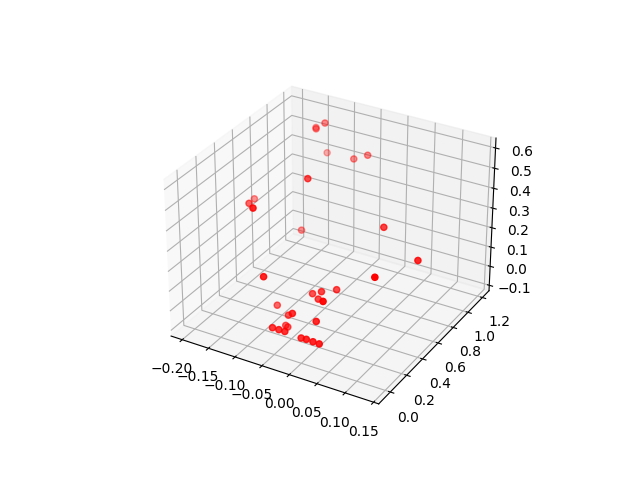

In [12]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#a = np.array([(pose_dataset[index][0][0,:][i].item(), pose_dataset[index][0][0,:][i+1].item(),pose_dataset[index][0][0,:][i+2].item()) for i in range(0,len(pose_dataset[index][0][0,:]),3)])
xs = pose_dataset[0][0][0][:,0]
ys = pose_dataset[0][0][0][:,1]
zs = pose_dataset[0][0][0][:,2]

ax.scatter(xs,ys,zs, c='r', marker='o')
#ax.set_box_aspect([np.ptp(xs), np.ptp(ys), np.ptp(zs)])

plt.show()

In [136]:
pose_dataset[idx].shape

AttributeError: 'tuple' object has no attribute 'shape'

In [141]:
a = np.array([(pose_dataset[idx][0][0,:][i].item(), pose_dataset[idx][0][0,:][i+1].item(),pose_dataset[idx][0][0,:][i+2].item()) for i in range(0,len(pose_dataset[idx][0][0,:]),3)])
xs = a[:,0]
ys = a[:,1]
zs = a[:,2]
ys

array([-0.74804688, -0.87158203, -0.87695312, -0.88183594, -0.86083984,
       -0.85888672, -0.85742188, -0.86865234, -0.83544922, -0.66796875,
       -0.65283203, -0.40380859, -0.39672852,  0.62158203,  0.46069336,
        0.19396973, -0.0041275 ,  0.07843018, -0.13061523, -0.06604004,
       -0.2454834 , -0.03025818, -0.17468262,  0.93261719,  0.79638672,
        1.36425781,  1.18847656,  2.32226562,  2.19726562,  2.3984375 ,
        2.26953125,  2.640625  ,  2.484375  ])

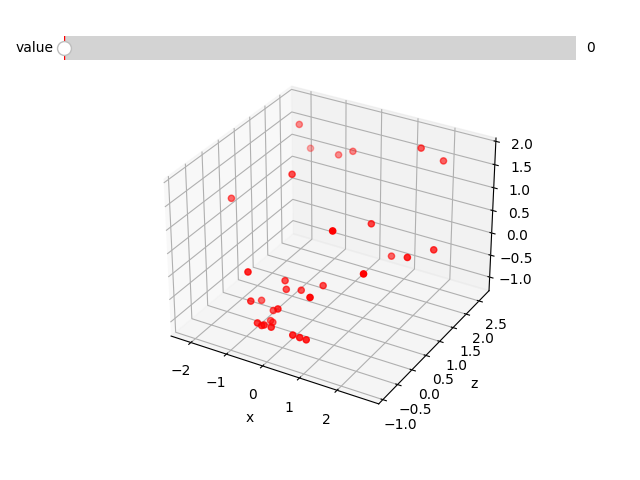

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib ipympl

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
idx = 0


ax2 = fig.add_axes([0.1, 0.85, 0.8, 0.1])

s = Slider(ax = ax2, label = 'value', valmin = 0, valmax = pose_dataset[idx][0].shape[0], valinit = 0, valstep=1)

def update(val):
    a = np.array([(pose_dataset[idx][0][val,:][i].item(), pose_dataset[idx][0][val,:][i+1].item(),pose_dataset[idx][0][val,:][i+2].item()) for i in range(0,len(pose_dataset[idx][0][val,:]),3)])
    xs = a[:,0]
    ys = a[:,1]
    zs = a[:,2]
    #xs = pose_dataset[idx][0][val][:,0]
    #ys = pose_dataset[idx][0][val][:,1]
    #zs = pose_dataset[idx][0][val][:,2]
    ax.cla()
    ax.scatter(xs,ys,zs, c='r', marker='o')    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylabel("z")

s.on_changed(update)

update(0)


plt.show()

In [124]:
a[:,0]

array([ 0.34960938, -0.60498047,  0.79541016,  0.97412109, -0.01238251,
        0.18383789, -0.36669922, -1.07324219, -0.61425781,  0.70751953,
        0.02191162, -2.09570312, -1.28515625, -2.453125  , -2.20507812,
        0.54785156,  0.99902344, -0.04284668,  0.64453125,  0.2467041 ,
       -0.48095703,  0.30761719, -0.52294922,  1.25585938,  0.78564453,
       -1.48242188,  2.72851562,  0.74755859,  1.75683594, -0.40478516,
        1.55566406, -1.81054688,  2.0078125 ])

ValueError: can only call '.item()' if the Series is of length 1, or an explicit index is provided (Series is of length 0)

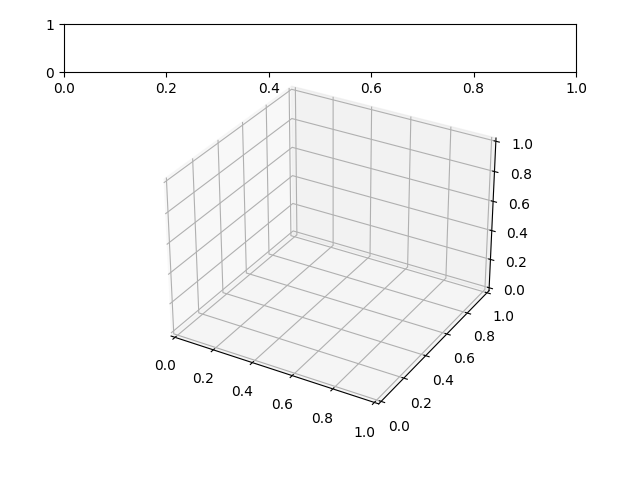

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib ipympl

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
idx = 0

a = np.array([(pose_dataset[idx][0][0,:][i].item(), pose_dataset[idx][0][0,:][i+1].item(),pose_dataset[idx][0][0,:][i+2].item()) for i in range(0,len(pose_dataset[idx][0][0,:]),3)])

ax2 = fig.add_axes([0.1, 0.85, 0.8, 0.1])

s = Slider(ax = ax2, label = 'value', valmin = 0, valmax = pose_dataset[i][0].shape[0], valinit = 0, valstep=1)

def update(val):
    xs = a[:,0]
    ys = a[:,1]
    zs = a[:,2]
    #xs = pose_dataset[idx][0][val][:,0]
    #ys = pose_dataset[idx][0][val][:,1]
    #zs = pose_dataset[idx][0][val][:,2]
    ax.cla()
    ax.scatter(xs,ys,zs, c='r', marker='o')

s.on_changed(update)

update(0)


plt.show()

In [66]:
[12,2,3,5]+[5,4,7]

[12, 2, 3, 5, 5, 4, 7]

In [12]:
lips = [61,39,0,269,291,405,17,181] 
eye_r = [33,159,133,145]
eyebrow_r = [46,52,65,55]
eye_l = [263,386,362,374]
eyebrow_l = [276,282,295,285]
poses = [["face",lips+eye_r+eye_l+eyebrow_r+eyebrow_l]]
print("Load {name} train dataset.".format(name=data_name))
face_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=15,
                            min_samples=20)
print("Train dataset size: {dataset_size}".format(dataset_size=len(face_dataset)))

Load LSFB train dataset.
Train dataset size: 53917


In [13]:
face_dataset[0][0][1]

tensor([ 0.0003, -0.0015, -0.0006,  0.0105, -0.0115, -0.0136,  0.0231, -0.0154,
        -0.0163,  0.0331, -0.0169, -0.0108,  0.0392, -0.0100,  0.0046,  0.0349,
         0.0018, -0.0030,  0.0249,  0.0079, -0.0055,  0.0118,  0.0069, -0.0056,
        -0.0320, -0.0928, -0.0038, -0.0200, -0.0972, -0.0105, -0.0038, -0.0987,
        -0.0061, -0.0169, -0.0938, -0.0084,  0.0525, -0.1118,  0.0049,  0.0415,
        -0.1165, -0.0040,  0.0282, -0.1041, -0.0022,  0.0413, -0.1041, -0.0020,
        -0.0443, -0.1048, -0.0104, -0.0292, -0.1143, -0.0191, -0.0167, -0.1159,
        -0.0208,  0.0000, -0.1133, -0.0207,  0.0577, -0.1262, -0.0003,  0.0443,
        -0.1324, -0.0122,  0.0346, -0.1298, -0.0161,  0.0220, -0.1210, -0.0184])

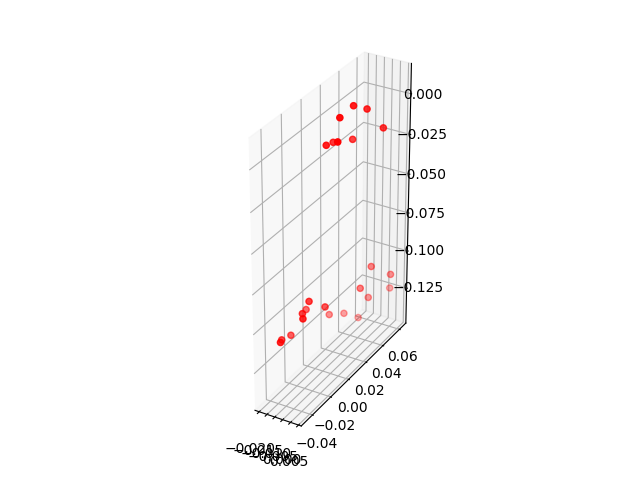

In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

a = np.array([[face_dataset[0][0][1][i].item(),face_dataset[0][0][1][i+1].item(),face_dataset[0][0][1][i+2].item()] for i in range(0,len(face_dataset[0][0][1]),3)])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

y = a[:,0]
z = a[:,1]
x = a[:,2]

ax.scatter(x, y, z, c='r', marker='o')
ax.set_box_aspect([np.ptp(x), np.ptp(y), np.ptp(z)])

plt.show()

In [9]:
import numpy as np
import os
pose_data = np.load(os.path.join(data_dir, 'poses', 'pose', 'CLSFBI0103A_S001_B_251203_251361.npy'))
pose_data


array([[[ 3.9233e-01,  2.8491e-01, -8.0176e-01],
        [ 3.9551e-01,  2.4548e-01, -7.4854e-01],
        [ 4.0723e-01,  2.4329e-01, -7.4902e-01],
        ...,
        [ 3.3398e-01,  1.6816e+00,  2.7930e-01],
        [ 4.5850e-01,  1.7480e+00,  1.3954e-02],
        [ 3.4302e-01,  1.7451e+00,  4.2908e-02]],

       [[ 3.9404e-01,  2.8491e-01, -7.6270e-01],
        [ 3.9624e-01,  2.4536e-01, -7.0996e-01],
        [ 4.0747e-01,  2.4316e-01, -7.1045e-01],
        ...,
        [ 3.3276e-01,  1.6768e+00,  1.8604e-01],
        [ 4.6021e-01,  1.7432e+00, -1.3222e-02],
        [ 3.4155e-01,  1.7402e+00, -4.9713e-02]],

       [[ 3.9600e-01,  2.8540e-01, -6.9238e-01],
        [ 3.9746e-01,  2.4536e-01, -6.4697e-01],
        [ 4.0796e-01,  2.4316e-01, -6.4746e-01],
        ...,
        [ 3.3203e-01,  1.6709e+00,  9.0759e-02],
        [ 4.6118e-01,  1.7373e+00, -5.7495e-02],
        [ 3.4082e-01,  1.7344e+00, -1.2488e-01]],

       ...,

       [[ 4.0015e-01,  2.8564e-01, -5.9717e-01],
        [ 4

IndexError: list index out of range

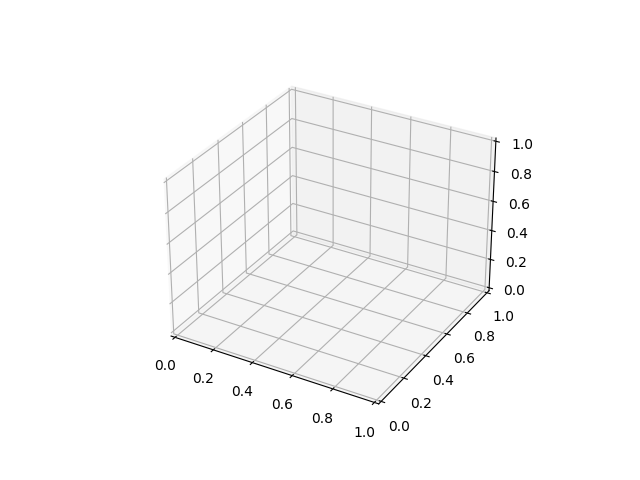

In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

def plot_world_landmarks(
    plt,
    ax,
    landmarks,
    visibility_th=0.5,
):
    landmark_point = []

    for index, landmark in enumerate(landmarks.landmark):
        landmark_point.append(
            [1, (landmark[:,0], landmark[:,1], landmark[:,2])])

    face_index_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    right_arm_index_list = [11, 13, 15, 17, 19, 21]
    left_arm_index_list = [12, 14, 16, 18, 20, 22]
    right_body_side_index_list = [11, 23, 25, 27, 29, 31]
    left_body_side_index_list = [12, 24, 26, 28, 30, 32]
    shoulder_index_list = [11, 12]
    waist_index_list = [23, 24]

    # 顔
    face_x, face_y, face_z = [], [], []
    for index in face_index_list:
        point = landmark_point[index][1]
        face_x.append(point[0])
        face_y.append(point[2])
        face_z.append(point[1] * (-1))

    # 右腕
    right_arm_x, right_arm_y, right_arm_z = [], [], []
    for index in right_arm_index_list:
        point = landmark_point[index][1]
        right_arm_x.append(point[0])
        right_arm_y.append(point[2])
        right_arm_z.append(point[1] * (-1))

    # 左腕
    left_arm_x, left_arm_y, left_arm_z = [], [], []
    for index in left_arm_index_list:
        point = landmark_point[index][1]
        left_arm_x.append(point[0])
        left_arm_y.append(point[2])
        left_arm_z.append(point[1] * (-1))

    # 右半身
    right_body_side_x, right_body_side_y, right_body_side_z = [], [], []
    for index in right_body_side_index_list:
        point = landmark_point[index][1]
        right_body_side_x.append(point[0])
        right_body_side_y.append(point[2])
        right_body_side_z.append(point[1] * (-1))

    # 左半身
    left_body_side_x, left_body_side_y, left_body_side_z = [], [], []
    for index in left_body_side_index_list:
        point = landmark_point[index][1]
        left_body_side_x.append(point[0])
        left_body_side_y.append(point[2])
        left_body_side_z.append(point[1] * (-1))

    # 肩
    shoulder_x, shoulder_y, shoulder_z = [], [], []
    for index in shoulder_index_list:
        point = landmark_point[index][1]
        shoulder_x.append(point[0])
        shoulder_y.append(point[2])
        shoulder_z.append(point[1] * (-1))

    # 腰
    waist_x, waist_y, waist_z = [], [], []
    for index in waist_index_list:
        point = landmark_point[index][1]
        waist_x.append(point[0])
        waist_y.append(point[2])
        waist_z.append(point[1] * (-1))
            
    ax.cla()
    ax.set_xlim3d(-1, 1)
    ax.set_ylim3d(-1, 1)
    ax.set_zlim3d(-1, 1)

    ax.scatter(face_x, face_y, face_z)
    ax.plot(right_arm_x, right_arm_y, right_arm_z)
    ax.plot(left_arm_x, left_arm_y, left_arm_z)
    ax.plot(right_body_side_x, right_body_side_y, right_body_side_z)
    ax.plot(left_body_side_x, left_body_side_y, left_body_side_z)
    ax.plot(shoulder_x, shoulder_y, shoulder_z)
    ax.plot(waist_x, waist_y, waist_z)
    
    plt.pause(.001)

    return

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_world_landmarks(plt, ax, pose_data, visibility_th=0.5)

In [20]:
pose_data[0][:,2]

array([-0.802   , -0.7485  , -0.749   , -0.749   , -0.744   , -0.7446  ,
       -0.7456  , -0.475   , -0.4946  , -0.678   , -0.6797  , -0.345   ,
       -0.2983  , -0.2445  , -0.4966  , -0.358   , -0.9795  , -0.4182  ,
       -1.103   , -0.4517  , -1.112   , -0.369   , -0.9946  , -0.00839 ,
        0.008446, -0.10675 , -0.1665  ,  0.2295  ,  0.2441  ,  0.2499  ,
        0.2793  ,  0.013954,  0.0429  ], dtype=float16)

In [13]:
for i in pose_data:
    print(i)

[[ 0.3923    0.285    -0.802   ]
 [ 0.3955    0.2455   -0.7485  ]
 [ 0.4072    0.2433   -0.749   ]
 [ 0.4165    0.2411   -0.749   ]
 [ 0.3662    0.2493   -0.744   ]
 [ 0.3552    0.2507   -0.7446  ]
 [ 0.3442    0.2532   -0.7456  ]
 [ 0.4148    0.252    -0.475   ]
 [ 0.326     0.2705   -0.4946  ]
 [ 0.411     0.317    -0.678   ]
 [ 0.377     0.319    -0.6797  ]
 [ 0.4836    0.4597   -0.345   ]
 [ 0.267     0.4944   -0.2983  ]
 [ 0.4895    0.756    -0.2445  ]
 [ 0.2344    0.815    -0.4966  ]
 [ 0.375     0.973    -0.358   ]
 [ 0.3171    0.76     -0.9795  ]
 [ 0.3508    1.027    -0.4182  ]
 [ 0.345     0.728    -1.103   ]
 [ 0.3215    1.016    -0.4517  ]
 [ 0.3481    0.6914   -1.112   ]
 [ 0.325     0.999    -0.369   ]
 [ 0.3445    0.701    -0.9946  ]
 [ 0.4653    0.954    -0.00839 ]
 [ 0.3174    0.9556    0.008446]
 [ 0.4893    1.322    -0.10675 ]
 [ 0.3186    1.293    -0.1665  ]
 [ 0.483     1.635     0.2295  ]
 [ 0.3308    1.632     0.2441  ]
 [ 0.4873    1.677     0.2499  ]
 [ 0.334  